In [1]:
!curl -L https://raw.githubusercontent.com/Denis2054/Transformers_3rd_Edition/master/Chapter16/generate_an_image_of_a_car_in_space.jpg --output "generate_an_image_of_a_car_in_space.jpg"

  % Total    % Received % Xferd  Average Speed   Time    Time     Time  Current
                                 Dload  Upload   Total   Spent    Left  Speed
100 32209  100 32209    0     0  87525      0 --:--:-- --:--:-- --:--:-- 87524


In [2]:
from IPython.display import Image # This is used for rendering images in the notebook

In [3]:
from PIL import Image
# Define the path of your image
image_path = "/content/generate_an_image_of_a_car_in_space.jpg"
# Open the image
image = Image.open(image_path)

In [4]:
import torchvision.transforms as transforms
import matplotlib.pyplot as plt

# Define the transformation
transform = transforms.Compose([
    transforms.Resize((224, 224)),  # Resize the image to 224*224
    transforms.ToTensor() # Convert the image to a PyTorch tensor
])

# Apply the transformation
pixel_values = transform(image).unsqueeze(0)  # Add an extra dimension for the batch size

patch_size = 16 # change to match the patch size used in your model

# Assuming pixel_values is your input image tensor of shape (batch_size, num_channels, height, width)
patches = pixel_values.unfold(2, patch_size, patch_size).unfold(3, patch_size, patch_size)
# patches will now have shape (batch_size, num_channels, num_patches_height, num_patches_width, patch_size, patch_size)

Displaying patch 1/196


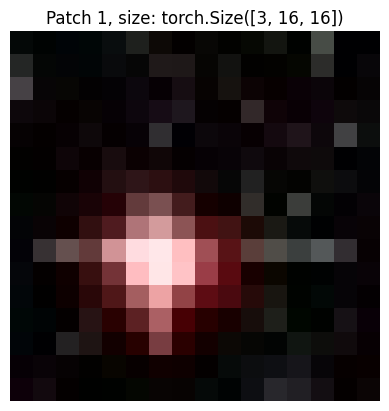

Displaying patch 2/196


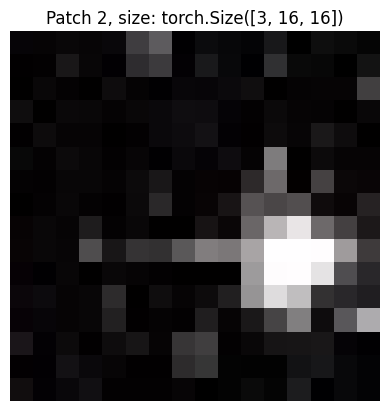

Displaying patch 3/196


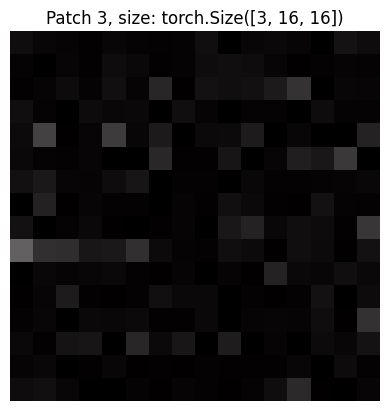

Displaying patch 4/196


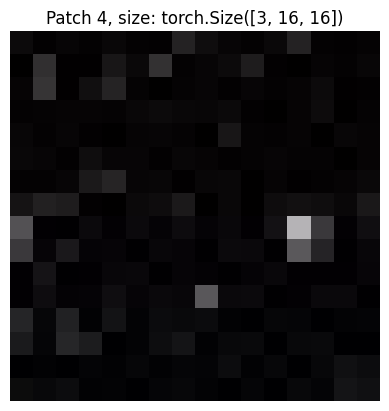

Displaying patch 5/196


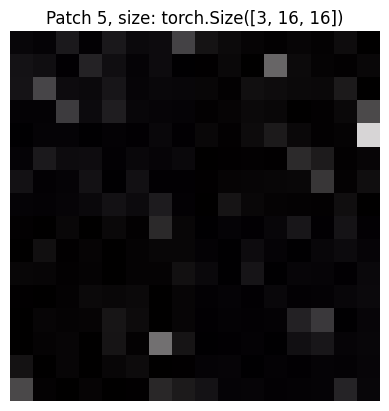

Displaying patch 6/196


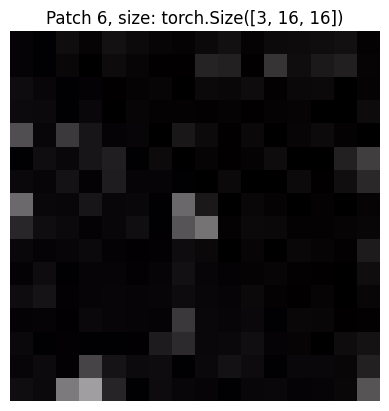

In [5]:
# Reshaping the patches tensor for easy viewing
patches_reshaped = patches.permute(0, 2, 3, 1, 4, 5).contiguous().view(-1, 3, patch_size, patch_size)

# create a transform to convert tensor to PIL Image
to_pil = transforms.ToPILImage()

k = 0
for i in range(patches_reshaped.size(0)):
  print(f"Displaying patch {i+1}/{patches_reshaped.size(0)}")
  patch_size = patches_reshaped[i].shape
  plt.title(f"Patch {i+1}, size: {patch_size}")
  plt.imshow(to_pil(patches_reshaped[i]))
  plt.axis("off") # to hide axes
  plt.show()
  # userInput = input("Press Enter to display the next patch (or 'q' to quit)... ")
  # if userInput.lower() == 'q':
  #   break
  if k == 5:
    break
  k += 1

In [6]:
from transformers import ViTImageProcessor, ViTForImageClassification

# Load the processor and model
processor = ViTImageProcessor.from_pretrained('google/vit-base-patch16-224')
model = ViTForImageClassification.from_pretrained('google/vit-base-patch16-224')

/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:112: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


preprocessor_config.json:   0%|          | 0.00/160 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/69.7k [00:00<?, ?B/s]

model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

Loading weights:   0%|          | 0/200 [00:00<?, ?it/s]

In [7]:
inputs = processor(images=image, return_tensors="pt")

In [8]:
outputs = model(**inputs)
logits = outputs.logits

In [9]:
# model predicts one of the 1000 ImageNet classes
predicted_class_idx = logits.argmax(-1).item()
print("Predicted class:", predicted_class_idx, ": ", model.config.id2label[predicted_class_idx])

Predicted class: 627 :  limousine, limo


In [13]:
print(inputs['pixel_values'].shape)

torch.Size([1, 3, 224, 224])


In [14]:
model

ViTForImageClassification(
  (vit): ViTModel(
    (embeddings): ViTEmbeddings(
      (patch_embeddings): ViTPatchEmbeddings(
        (projection): Conv2d(3, 768, kernel_size=(16, 16), stride=(16, 16))
      )
      (dropout): Dropout(p=0.0, inplace=False)
    )
    (encoder): ViTEncoder(
      (layer): ModuleList(
        (0-11): 12 x ViTLayer(
          (attention): ViTAttention(
            (attention): ViTSelfAttention(
              (query): Linear(in_features=768, out_features=768, bias=True)
              (key): Linear(in_features=768, out_features=768, bias=True)
              (value): Linear(in_features=768, out_features=768, bias=True)
            )
            (output): ViTSelfOutput(
              (dense): Linear(in_features=768, out_features=768, bias=True)
              (dropout): Dropout(p=0.0, inplace=False)
            )
          )
          (intermediate): ViTIntermediate(
            (dense): Linear(in_features=768, out_features=3072, bias=True)
            (intermed

In [15]:
print(outputs.logits.shape)

torch.Size([1, 1000])


In [16]:
model.config.id2label

{0: 'tench, Tinca tinca',
 1: 'goldfish, Carassius auratus',
 2: 'great white shark, white shark, man-eater, man-eating shark, Carcharodon carcharias',
 3: 'tiger shark, Galeocerdo cuvieri',
 4: 'hammerhead, hammerhead shark',
 5: 'electric ray, crampfish, numbfish, torpedo',
 6: 'stingray',
 7: 'cock',
 8: 'hen',
 9: 'ostrich, Struthio camelus',
 10: 'brambling, Fringilla montifringilla',
 11: 'goldfinch, Carduelis carduelis',
 12: 'house finch, linnet, Carpodacus mexicanus',
 13: 'junco, snowbird',
 14: 'indigo bunting, indigo finch, indigo bird, Passerina cyanea',
 15: 'robin, American robin, Turdus migratorius',
 16: 'bulbul',
 17: 'jay',
 18: 'magpie',
 19: 'chickadee',
 20: 'water ouzel, dipper',
 21: 'kite',
 22: 'bald eagle, American eagle, Haliaeetus leucocephalus',
 23: 'vulture',
 24: 'great grey owl, great gray owl, Strix nebulosa',
 25: 'European fire salamander, Salamandra salamandra',
 26: 'common newt, Triturus vulgaris',
 27: 'eft',
 28: 'spotted salamander, Ambystoma 

In [17]:
outputs.logits

tensor([[ 6.2552e-01, -9.8143e-01, -4.9785e-01,  2.6510e-02, -5.4599e-01,
         -3.6268e-02, -3.6015e-01, -5.6295e-01, -1.7575e-01,  2.6453e-01,
          9.5287e-01, -4.8682e-01, -1.7794e-01,  4.5730e-01, -4.6610e-01,
          2.5773e-01, -1.0386e+00, -4.6353e-01,  9.8151e-02,  2.1295e-01,
          6.9664e-01, -8.3763e-01, -7.9977e-01, -1.6137e+00, -2.3889e-01,
          8.7438e-02, -2.9434e-01,  1.0718e-01, -2.1952e-01, -6.5871e-01,
          4.8004e-01, -6.1846e-01, -5.8381e-01, -5.3353e-01, -3.5650e-01,
          4.1239e-01, -1.0090e+00,  2.9560e-02,  3.9894e-01, -1.1910e+00,
         -1.1463e+00, -3.6976e-01, -5.3911e-01, -1.3875e+00, -7.4166e-01,
         -3.8134e-01, -6.1328e-01, -8.5938e-01, -1.5418e+00, -6.3527e-01,
         -1.2243e+00, -4.6310e-02,  1.4071e-01,  5.6486e-01, -7.3335e-01,
         -1.6195e-01, -4.0381e-01, -3.0757e-01, -2.9176e-01, -7.0381e-01,
          9.5711e-01, -1.8762e-01, -7.0865e-02, -4.0758e-01, -1.2576e-01,
         -1.2016e+00, -3.4443e-01,  2.

In [18]:
import torch
import pandas as pd

# Apply softmax to convert logits to probabilities
probs = torch.nn.functional.softmax(logits, dim=-1)

In [21]:
# Get the top 5 predicted class probabilities and their corresponding indices
top_5_probs, top_5_labels = torch.topk(probs, 5)
top_5_probs = top_5_probs.detach().cpu().numpy()
top_5_labels = top_5_labels.detach().cpu().numpy()

# Get the mapping from IDs to labels
id2label = model.config.id2label

# Create a dictionary that maps the top 5 predictions to their corresponding labels and probabilities
pred_dict = {"Index": [], "Probability": [], "Label": []}
for i in range(5):
  pred_dict["Index"].append(top_5_labels[0][i])
  pred_dict["Probability"].append(top_5_probs[0][i])
  pred_dict["Label"].append(id2label[top_5_labels[0][i]])

# Convert the dictionary to a DataFrame
pred_df = pd.DataFrame(pred_dict)

# Display the DataFrame
pred_df

,Index,Probability,Label
0,627,0.848521,"limousine, limo"
1,436,0.043924,"beach wagon, station wagon, wagon, estate car,..."
2,817,0.033518,"sports car, sport car"
3,479,0.027506,car wheel
4,751,0.015660,"racer, race car, racing car"
